# Bullwhip-effekten

## Dynamikk i forsyningskjeder, innføring

I den forrige oppgaven så vi på likevekt i en forsyningskjede. Nå vi har sett på differensialligninger er vi i stand til å studere dynamikken (endringer i tid) i en slik kjede.

Vi begynner med den enkleste eksemplet, med bare en fabrikk. I den neste gruppeøvingen vil vi studere mer kompliserte kjeder, slik som vi så på forrige gang.

## En differensialligning

Husk at $A = D - C$ var matrisa med produksjonsratene? Den basic ligning blir:

$$
\frac{d\vec{q}}{dt} = A\vec{u},
$$

Hvor $\vec{q}$ er en vektor med lagerføring av forskjellige varer, og $\vec{u}$ er en vektor med produksjonsrater. For å gjør livet mer komplisert, er det generelt slik at vi justerer $\vec{u}(\vec{q})$ avhengig av lagerføringen.

## Den enkle kjeden

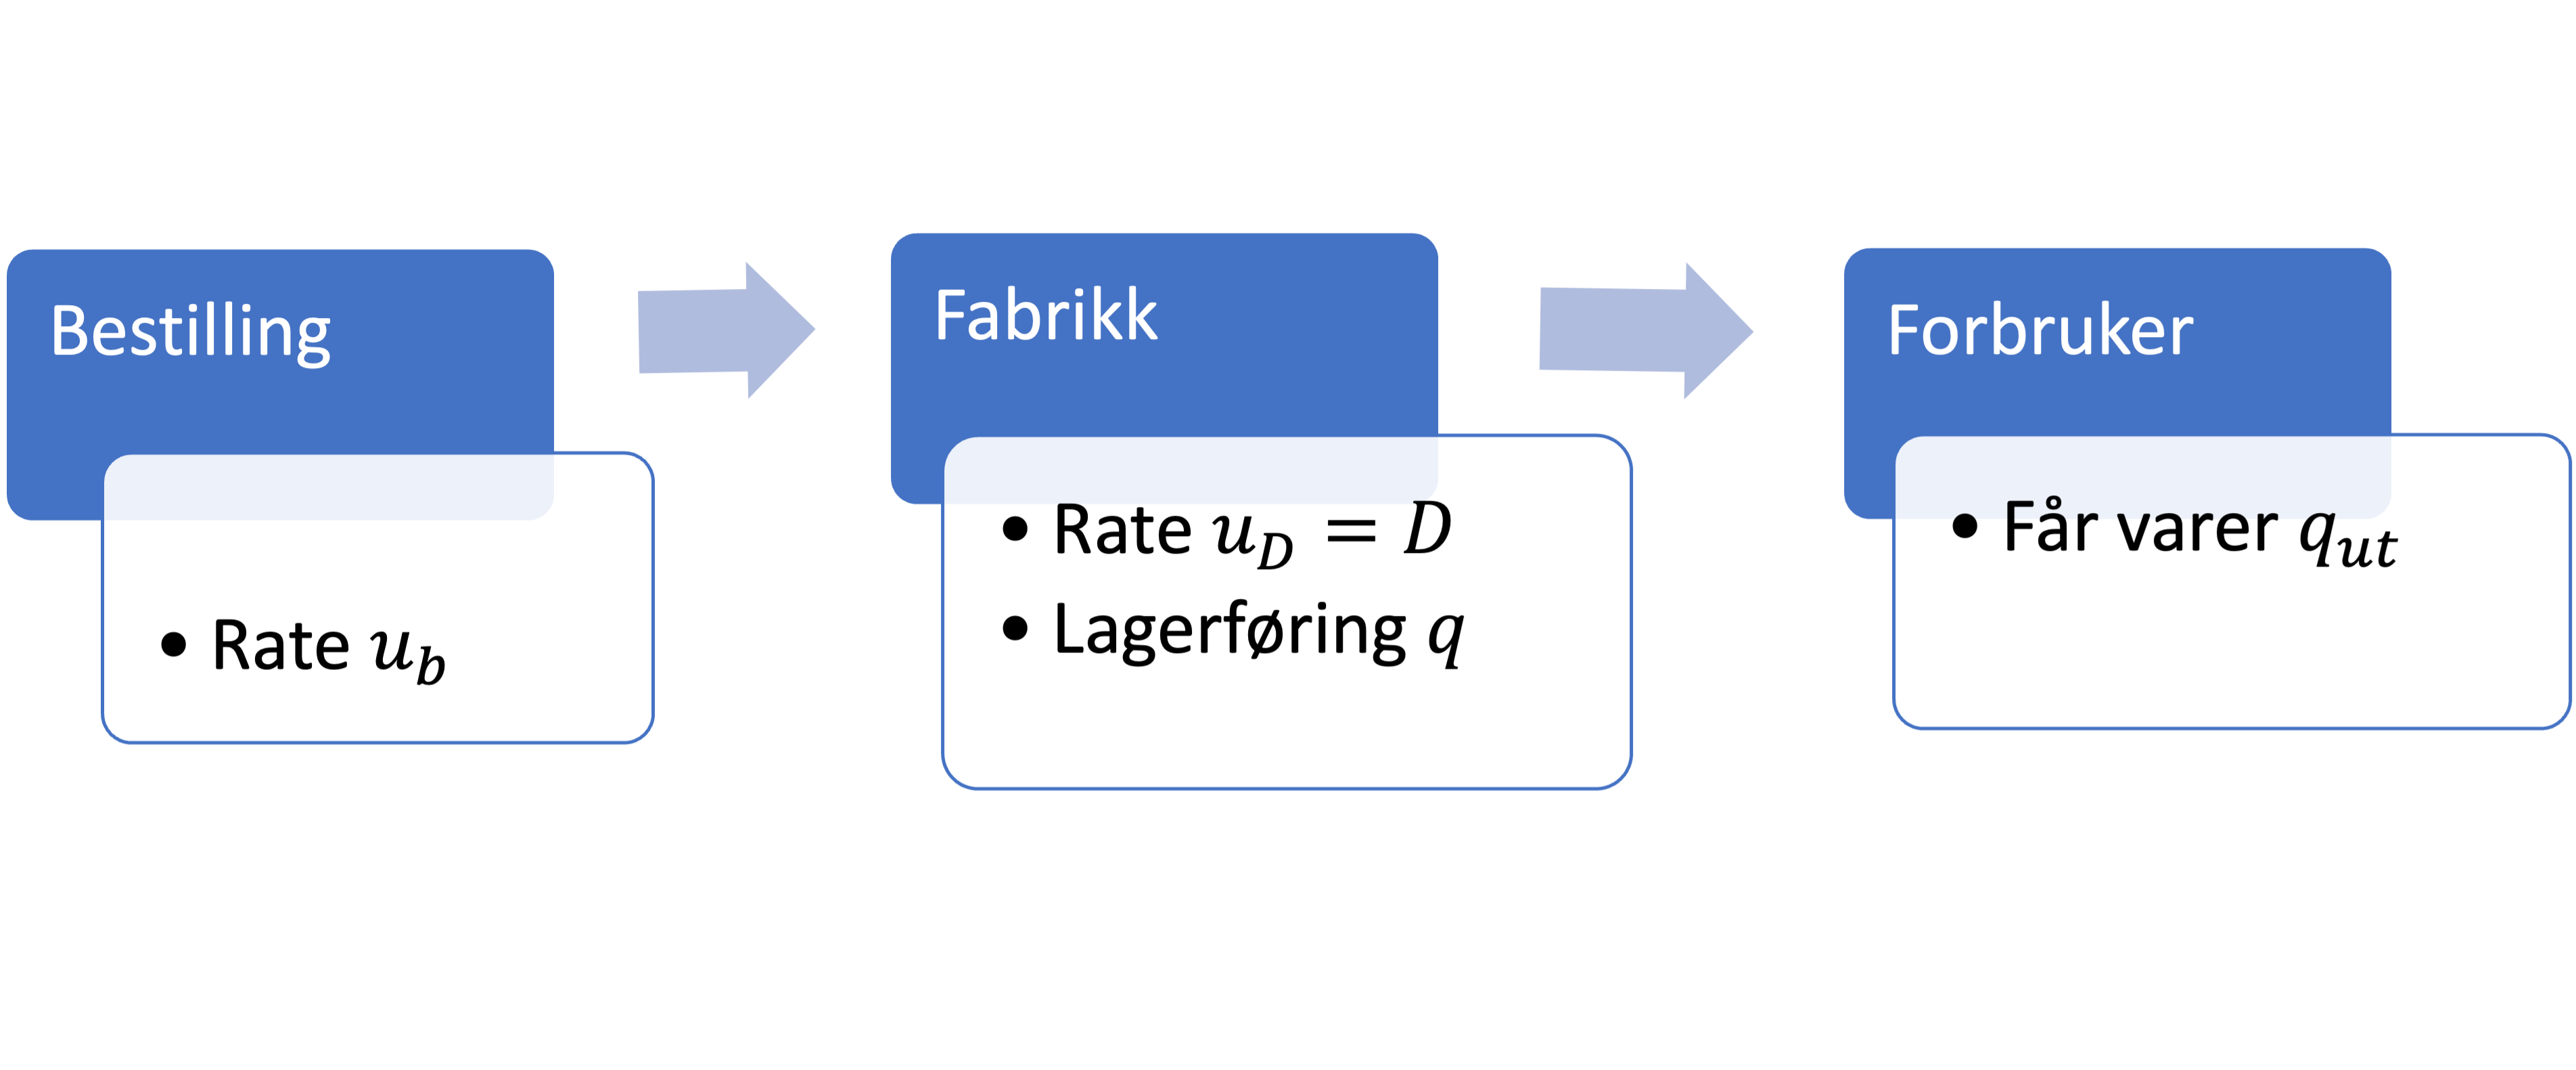

Den enkleste forsyninskjede har $\vec{q} = (q, q_{\mathrm{ut}})$, og $\vec{u}=(u_b, u_D)$, hvor "innhøstingen" $u_b$ er bestillingen til fabrikken, og $u_D$ er produksjonsrate på fabrikken, som vi antar følger nøyaktig etterspørsel $D$.

Matrisa blir
$$
A = 
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
-
\begin{pmatrix}
0 & 1 \\
0 & 0
\end{pmatrix}
=
\begin{pmatrix}
1 & -1 \\
0 & 1
\end{pmatrix}
$$

Det gir oss en ligning for lagerføring $q$:

$$
\frac{dq}{dt} = u_b(q, t) - u_D(t) = u_b(q, t) - D
$$


## Bestillingsstrategi

Den enkleste bestillingsstrategi er å ta $u_b(q, t) = \frac{q_D - q(t)}{T}$ hvor $q_D$ er ønsket lagerføring, slik at vi "tar igjen" $q_D$ etter en bestemt tid $T$.

Problemet er at i den reelle verden oppstår det ofte forsinkelse mellom da vi ønsker og endre produskjonsrate, og når den reelle forandring skjer. Da er det mer realistisk at

$$u_b(t) = \frac{q_D - q(t-t_G)}{T},$$

hvor $t_G$ er en forsinkelsestid. 


## Den forsinkede ligningen

Det fører til følgende modell av et ledd i kjeden

$$
\frac{dq}{dt} + \frac{q(t-T_G)}{T} = \frac{q_D}{T} - D.
$$

Her er $D$ etterspørsel (det kan varierer med tid, men for øyeblikket antas konstant), $q_D$ er ønsket lagerføring og $q_0$ er initial lagerføring. Parametrene $T, T_G$ står for flere forsinkelser i systemet: $T_G$ er tiden det tar å reagere på endret lagerføring og $T$ er en bestillingstid. 

Den er teknisk sett ikke en vanlig ordinær differensialligning, men heller en forsinket ODL. Men vi kan fortsett løser det mer Eulers metode, vi må bare justere koden litt (se under):

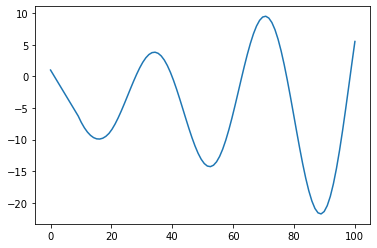

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def forsinkede(D,T,TG,q0,qd,a,b,N):
    t = np.linspace(a,b,N)
    h = (b-a)/(N-1)
    q = np.zeros(N)
    q[0] = q0
    j = int(TG/h)
    for i in np.arange(N-1):
        q[i+1] = q[i] + h*((qd-q[i-j])/T-D)
    return q, t

fig, ax = plt.subplots()

q, t = forsinkede(1,5,10,1,1,0,100,100)

ax.plot(t,q)

## Oppgave 1

Vi ser på bullwhip-effekt, hvor voldsomme endringer i lagerføring kan oppstår, selv uten vesentlige endringer i etterspørsel.

1. Kjør koden for forskjellige verdier av $q_D, T, T_G$
2. Kommenter resultatene. Får du en bullwhip effekt? Ser svarene realistisk ut?
3. (Vanskelig) Vi burde egentlig ikke tillate negativ lagerføring. Det er heller ikke noe vits i å overprodusere vesentlig bare for å få ned lagerbeholdning som er over ønsket nivå. Kan du endre ligning slik at vi tar høyde for det?

Hint: en måte å hindre overproduksjon er å ta 

$$
u_b(t) = \mathrm{max}\left(\frac{q_D - q(t-t_G)}{T},0\right)
$$

Vi stopper produksjon ved å sikre at $\frac{dq}{dt}\geq 0$ hvis $q(t)=0$, altså

$$
u_b(t) = \mathrm{max}\left(\frac{q_D - q(t-t_G)}{T}, D\right), \qquad \mathrm{hvis}\quad q(t)=0.
$$

## Løsning

1. Bare å leke litt rundt her
2. Det kan bli voldsomt ja!
3. Se under:

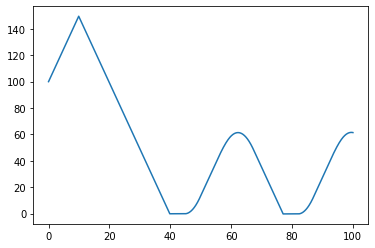

In [24]:
def forsinkede2(D,T,TG,q0,qd,a,b,N):
    t = np.linspace(a,b,N)
    h = (b-a)/(N-1)
    q = np.zeros(N)
    q[0] = q0
    j = int(TG/h)
    for i in np.arange(N-1):
        if q[i]<=0:
            p = max((qd-q[i-j])/T-D,0)
        else:
            p = max((qd-q[i-j])/T,0)-D
        q[i+1] = q[i] + h*p
    return q, t

fig, ax = plt.subplots()

q3, t = forsinkede2(5,5,10,100,50,0,100,1000)

ax.plot(t,q3)

## Ligning 2: andreordens

En alternativ modell bruker en andreordens ligning (det er en viss bestillingsstrategi som ligger bak, men vi går ikke inn i detaljene her). Da får vi et andreordens system:

$$
\frac{d^2 q}{dt^2} + \frac{1}{T_G}\frac{dq}{dt} + \frac{1}{T_G T}q = \frac{q_D}{T_G T}
$$

Her er $T, T_G, q_D$ som før, mens vi antar at $d=0$.

## Oppgave 2

1. Velg verdier til $T, T_G, q_D$ og løs systemet analytisk.
2. Sammenlign resultatene med den fra Oppgave 1 (Bruk gjerne kodefeltet under)
3. Hva som er mest realistisk?

## Løsning

1. Løsninger blir $q = q_D + Ae^{\lambda_1 t} + Be^{\lambda_2 t}$, hvor $\lambda_i$ er røttene til den karakteristiske ligningen,

$$
\lambda = \frac{-T \pm \sqrt{T^2 - 4T_G T}}{2T_G T}
$$

Hvis vi tar $T=5,T_G=10$ får vi

$$
\lambda = \frac{-5 \pm \sqrt{-175}}{100} = \frac{-1 \pm i \sqrt{7}}{20}
$$

Slik at

$$
q = q_D + A e^{-0.05 t}\sin(0.132 t + \phi)
$$

2. Vi plotter under

3. Den andreordens modell er mer stabil. Er den mer realistisk? Trolig er den forsinkede ligningen å foretrekke.

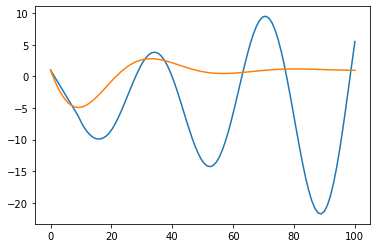

In [5]:
#def analytisk(T_G, T, D)
    # sett inn svaret ditt her

#q1 = forsinkede(#sett inn)

def analytisk(t,A,phi):
    return 1 + A*np.exp(-0.05*t)*np.sin(0.132*t + phi)
    
q2 = analytisk(t, -10, 0)


fig2, ax2 = plt.subplots()

ax2.plot(t,q)
ax2.plot(t,q2)